# Αναγνώριση 27 Κατηγοριών της Αμερικανικής Νοηματικής Γλώσσας


### Κωνσταντίνος Τσουμελέας

## Dataset

Διάφορα σύνολα δεδομένων σχετίζονται με την Αμερικανική Νοηματική Γλώσσα. Σε αυτό το συγκεκριμένο παράδειγμα, χρησιμοποιήθηκε ένα σύνολο δεδομένων με 27 κατηγορίες. Σημαντικό για την προεπεξεργασία των δεδομένων είναι η κατανόηση της μορφής τους. Συνεπώς, διαβάζοντας την εργασία που εκπνοήθηκε από τους δημιουργούς του συνόλου δεδομένων, εξάγονται οι παρακάτω πληροφορίες:

* Τα δεδομένα προέρχονται από 173 εθελοντές.
* Οι χειρονομίες διαμορφώνονται χρησιμοποιώντας το δεξί χέρι.
* Περιλαμβάνει τους αριθμούς: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9 (στατικές χειρονομίες).
* Περιλαμβάνει τα γράμματα: A, B, C, D, E (στατικές χειρονομίες).
* Περιλαμβάνει εκφράσεις: Hello, Yes, No, Good, Bye, Good morning, Pardon, Project, Little bit, Please, What’s up (δυναμικές χειρονομίες).
* Περιέχει την κατηγορία NULL: 314 εικόνες χωρίς καμία χειρονομία και με διαφορετικό φόντο.
* Οι εικόνες καταγράφηκαν χρησιμοποιώντας κάμερα RGB με ανάλυση καρέ 3024 x 3024 pixel.
* Μέγεθος εικόνων: 128 x 128.
* Οι εικόνες είναι κανονικοποιημένες.
* Τραβήχτηκαν 130 εικόνες από κάθε άτομο, 5 από κάθε κατηγορία.
* Συνολικός αριθμός εικόνων: 22.801.
* Οι επεξεργασμένες εικόνες αποθηκεύτηκαν σε έναν numpy Tensor ‘X’ με 4 διαστάσεις (αριθμός εικόνων, ύψος εικόνας, πλάτος εικόνας, κανάλια RGB).
* Δημιουργήθηκε ένας numpy Tensor ‘Y’, που περιέχει τις ετικέτες των εικόνων και έχει 2 διαστάσεις (αριθμός εικόνων, 1). Δηλαδή, κάθε εικόνα αντιστοιχεί σε μία ετικέτα.

## Import Packages

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

## **Dataset Management**

### Data Loading

In [20]:
import numpy as np

x_data = np.load(r"C:\Users\kostas\Desktop\JUPYTER\X.npy\X.npy")
y_data = np.load(r"C:\Users\kostas\Desktop\JUPYTER\Y.npy\Y.npy")

### Data Shaping

In [3]:
print("Tensor with images has shape: ", x_data.shape)
print("Tensor with labels has shape: ", y_data.shape)
print("An image has shape: ", x_data.shape[1::])

Tensor with images has shape:  (22801, 128, 128, 3)
Tensor with labels has shape:  (22801, 1)
An image has shape:  (128, 128, 3)


### Identifying and Visualising Classes

Στο παρακάτω κελί, αναγνωρίζονται οι μοναδικές ετικέτες που εμφανίζονται. Αυτή η διαδικασία θα επιστρέψει τα μοναδικά στοιχεία του τανυστή ετικετών ταξινομημένα. Ως αποτέλεσμα, η μεταβλητή "classes" θα περιέχει την ετικέτα κάθε κατηγορίας ταξινομημένη.

In [29]:
# Classes
classes = np.unique(y_data)
print("Classes are: ", classes)

Classes are:  ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9' 'NULL' 'a' 'b' 'bye' 'c' 'd' 'e'
 'good' 'good morning' 'hello' 'little bit' 'no' 'pardon' 'please'
 'project' 'whats up' 'yes']


### Single Image Display

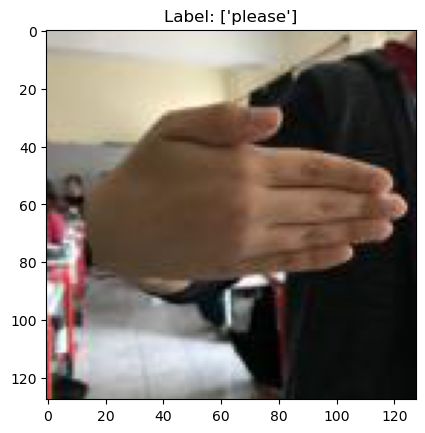

In [70]:
# Plot only the image at index 133 with it's label
image = x_data[133]
label = y_data[133]
1
plt.imshow(image)
plt.title(f"Label: {label}")
plt.show()

### Visualizing one Image from Each Class

Σε αυτό το σύνολο δεδομένων, που περιέχει 27 κατηγορίες, επιλέχθηκε να χρησιμοποιηθεί μια διάταξη με 3 σειρές και 9 στήλες. Για κάθε κατηγορία, εμφανίζεται η πρώτη εικόνα, συνοδευόμενη από την ετικέτα που υποδεικνύει την κατηγορία της.

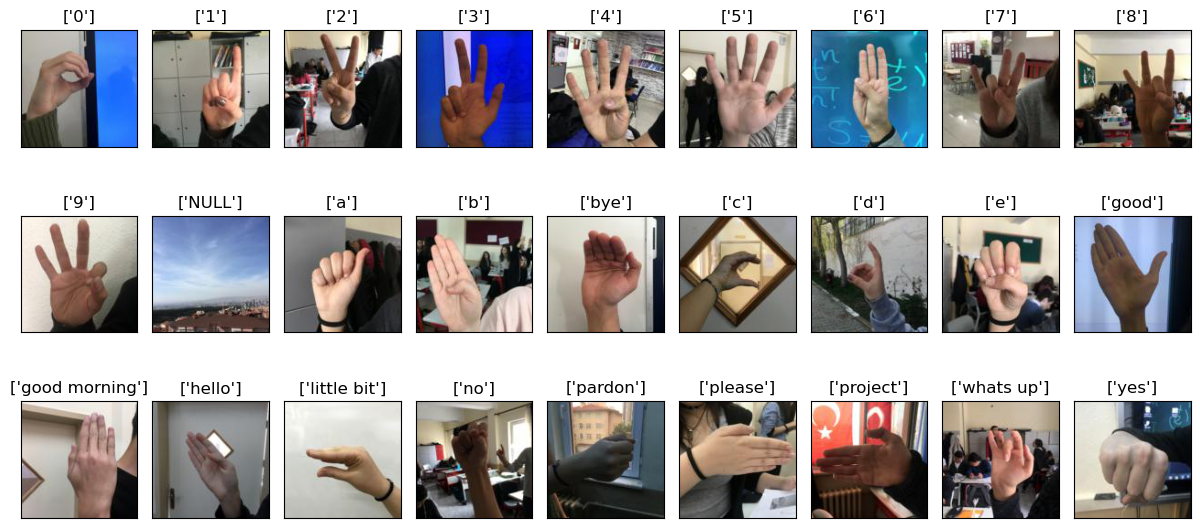

In [56]:
# Create subplots with 3 rows and 9 columns
fig, axs = plt.subplots(3, 9, figsize=(12, 6), subplot_kw={'xticks': [], 'yticks': []}) # xticks and yticks as a list means the axis will not be displayed.

# Loop through each label and plot one image of the class with it's label
for i, label in enumerate(classes):
    # Get the index of the first instance of this label
    index = np.where(y_data == label)[0][0]
    
    # Get the corresponding image and label
    image = x_data[index]
    label = y_data[index]
    
    # Plot the image with it's label in the corresponding subplot
    axs[i // 9, i % 9].imshow(image) # i // 9 (floor division) gives the row index, i % 9 (modulus) gives the column index 
    axs[i // 9, i % 9].set_title(f"{label}")

# Show the plot
plt.tight_layout()
plt.show()

### *One-Hot Encoding*

Αρχικά, κάθε κατηγορία θα αντιστοιχιστεί σε έναν μοναδικό ακέραιο αριθμό, δημιουργώντας ένα λεξικό ετικετών (label dictionary). Το λεξικό αυτό χρησιμοποιείται στο επόμενο κελί για να επιτευχθεί η κωδικοποίηση One-Hot Encoding. Μέσω αυτής της διαδικασίας, οι κατηγορίες αντιστοιχίζονται σε ακέραιους αριθμούς, οι οποίοι στη συνέχεια μετατρέπονται σε διανύσματα δυαδικής κωδικοποίησης (One-Hot Encoded). Με αυτή την τεχνική, οι κατηγορίες μετατρέπονται σε δυαδικά διανύσματα όπου κάθε κατηγορία αντιπροσωπεύεται από 0 ή 1, και το μήκος κάθε διανύσματος είναι ίσο με τον αριθμό των μοναδικών κατηγοριών. Επειδή τα νευρωνικά δίκτυα δέχονται αριθμητικά δεδομένα ως είσοδο, αυτός ο μετασχηματισμός είναι απαραίτητος για τη διαδικασία εκπαίδευσης.

In [61]:
# Define label dictionary
label_dict = {label: i for i, label in enumerate(classes)}
print("The label dictionary is: ", label_dict)

# Map the class names to integers using the label_dict dictionary
y_int = np.array([label_dict[label] for label in y_data.flatten()])

# Convert the integer labels to one-hot encoded vectors
y_cat = to_categorical(y_int, num_classes=len(label_dict)).astype(int)

The label dictionary is:  {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'NULL': 10, 'a': 11, 'b': 12, 'bye': 13, 'c': 14, 'd': 15, 'e': 16, 'good': 17, 'good morning': 18, 'hello': 19, 'little bit': 20, 'no': 21, 'pardon': 22, 'please': 23, 'project': 24, 'whats up': 25, 'yes': 26}


# Class Distribution

### *Υπολογισμός Εμφάνισης Κάθε Κατηγορίας*

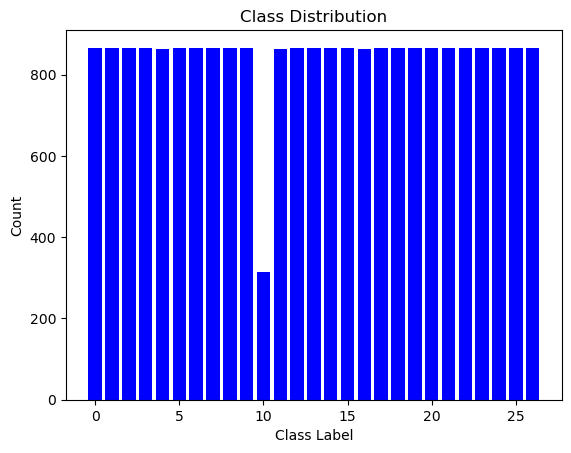

In [64]:
# Convert one-hot encoded labels back to integer labels
y_int_labels = np.argmax(y_cat, axis = 1)

# Count the occurrences of each class
class_counts = np.bincount(y_int_labels)
 
# Get the unique class labels
unique_labels = np.unique(y_int_labels)

# Plot the class distribution
plt.bar(unique_labels, class_counts, color = 'blue')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

# Data Augmentation (Ενίσχυση Δεδομένων)

Η τεχνική της ενίσχυσης δεδομένων (data augmentation) χρησιμοποιείται για να βελτιωθεί η γενίκευση του μοντέλου και να μειωθεί το φαινόμενο του overfitting. Το dataset περιέχει εικόνες χωρίς χειρονομίες και διαφορετικά φόντα, κάτι που ενισχύει την προσαρμοστικότητα του μοντέλου σε πραγματικές συνθήκες. Ωστόσο, λόγω του ανισοβαρούς αριθμού εικόνων στην κατηγορία NULL σε σχέση με τις υπόλοιπες, η ενίσχυση δεδομένων βοηθά στην εξισορρόπηση του συνόλου δεδομένων.

Επιπλέον, η τεχνική αυτή ωθεί το μοντέλο να μάθει πολύπλοκα χαρακτηριστικά από τις εικόνες, όπως τις διαφορές στα φόντα, βελτιώνοντας τη συνολική απόδοση. Στο πλαίσιο αυτό, εφαρμόζονται οι εξής μετασχηματισμοί:

* Τυχαία περιστροφή έως 0.1 radians.
* Τυχαίο zoom έως 0.1.
* Οριζόντια αναστροφή.

Αυτοί οι μετασχηματισμοί βοηθούν στη μοντελοποίηση διαφορετικών τρόπων εκτέλεσης των χειρονομιών, λαμβάνοντας υπόψη ότι υπάρχουν τόσο δεξιόχειρες όσο και αριστερόχειρες χρήστες.

In [81]:
from tensorflow import keras

data_augmentation = keras.Sequential([
    keras.layers.RandomRotation(0.1),       # Τυχαία περιστροφή
    keras.layers.RandomZoom(0.1),           # Τυχαίο zoom
    keras.layers.RandomFlip("horizontal")   # Οριζόντια αναστροφή
])


# Original vs Augmented Image

### Αναμενόμενες Διαφορές

Διαφορές ανάλογα με τους μετασχηματισμούς

1. Τυχαία Περιστροφή (Random Rotation)

* Η εικόνα μπορεί να είναι ελαφρώς περιστραμμένη γύρω από το κέντρο της.
* Αναμένεται να υπάρχει γωνιακή μετατόπιση έως το μέγιστο όριο που έουμε καθορίσει ( 0.1 radians).

2. Τυχαίο Zoom (Random Zoom)

* Η εικόνα μπορεί να φαίνεται ελαφρώς πιο κοντά (μεγεθυμένη) ή πιο μακριά (σμίκρυνση).
* Ορισμένα περιθώρια της εικόνας μπορεί να "κοπούν" ή να είναι κενά.
  
3. Οριζόντια Αναστροφή (Horizontal Flip)

* Η εικόνα μπορεί να έχει αναστραφεί οριζόντια, δηλαδή να εμφανίζεται σαν καθρέφτης.

4. Συνδυασμοί Μετασχηματισμών

* Εάν εφαρμόζονται πολλοί μετασχηματισμοί μαζί, η τελική εικόνα μπορεί να έχει περιστροφή, zoom και καθρέφτισμα ταυτόχρονα.

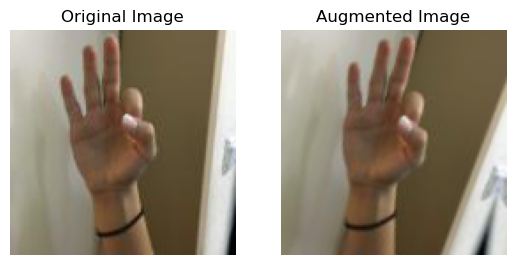

In [93]:
# Original sample image
original_image = x_data[3000]

# Display the original image
plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title('Original Image')
plt.axis('off')

# Augment the image using the data augmentation pipeline
augmented_image = data_augmentation(tf.expand_dims(original_image, 0), training = True)
augmented_image = augmented_image[0].numpy()

# Display the augmented image
plt.subplot(1, 2, 2)
plt.imshow(augmented_image)
plt.title('Augmented Image')
plt.axis('off')
plt.show()

# Trainning Phase

Το dataset χωρίζεται σε σύνολο εκπαίδευσης και σύνολο δοκιμής, όπου το 30% των δεδομένων προορίζεται για τη δοκιμή του μοντέλου. Με τη χρήση της παραμέτρου "random_state", εξασφαλίζεται ότι η τυχαία δειγματοληψία παραμένει σταθερή σε κάθε εκτέλεση.

### Dataset Splitting

In [104]:
# Split data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x_data, y_cat, test_size = 0.3, random_state = 42)

print("x_train shape is:", x_train.shape) # Train set images
print("y_train shape is:", y_train.shape) # Train set labels
print("x_test shape is:", x_test.shape) # Test set images
print("y_test shape is:", y_test.shape) # Test set labels

x_train shape is: (15960, 128, 128, 3)
y_train shape is: (15960, 27)
x_test shape is: (6841, 128, 128, 3)
y_test shape is: (6841, 27)


# Building Our Model

### Υλοποίηση Νευρωνικού Δικτύου

Στο επόμενο κελί σχεδιάζεται η αρχιτεκτονική ενός Συνελικτικού Νευρωνικού Δικτύου (CNN) με τα παρακάτω χαρακτηριστικά:

1. Ενίσχυση δεδομένων(Data Augmentation) για βελτίωση της γενίκευσης.
 
2. Συνελικτικό επίπεδο (Convolutional Layer) με:

* 64 φίλτρα,
* μέγεθος πυρήνα (kernel size) 3x3,
*  συνάρτηση ενεργοποίησης ReLU.

* * Τα 64 φίλτρα σημαίνουν ότι θα εξαχθεί ένας χάρτης με 64 χαρακτηριστικά (feature map). Το μέγεθος πυρήνα 3x3 αναφέρεται στο παράθυρο ολίσθησης κατά τη διάρκεια της συνέλιξης, ενώ η συνάρτηση ReLU προσθέτει μη-γραμμικότητα στο δίκτυο. Ως είσοδος χρησιμοποιούνται οι εικόνες, επομένως το input_shape ορίζεται στο μέγεθος κάθε εικόνας.

3. MaxPooling επίπεδα: Τρία επίπεδα για μείωση της διάστασης των δεδομένων, με χρήση περιοχών 2x2.

4. Flatten επίπεδο: Μετατροπή τρισδιάστατων δεδομένων σε μονοδιάστατα.

5. Πλήρως συνδεδεμένα επίπεδα:

* Δύο επίπεδα με 256 και 512 νευρώνες, αντίστοιχα, και συναρτήσεις ενεργοποίησης ReLU.
* Τελικό επίπεδο με αριθμό νευρώνων ίσο με τις κατηγορίες και χρήση της συνάρτησης ενεργοποίησης softmax.

In [116]:
from tensorflow.keras.layers import Input

# Build the model
model = keras.Sequential([
    Input(shape=(128, 128, 3)),  # Προσθήκη του Input Layer
    data_augmentation,
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(256, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(len(label_dict), activation='softmax')
])


# Model Trainning

### *Additional Optimizations*

Το μοντέλο εκπαιδεύεται με τις εξής τεχνικές:

1. Adam Optimizer: Ένας αποτελεσματικός αλγόριθμος βελτιστοποίησης που χρησιμοποιείται για τη ρύθμιση των παραμέτρων του μοντέλου.

2. Learning Rate: Ένας σταθερός ρυθμός μάθησης 0.001 επιλέγεται για σταθερή και αποτελεσματική εκπαίδευση.

3. Categorical Crossentropy: Συνάρτηση απώλειας για προβλήματα πολυκατηγορικής ταξινόμησης.

4. Accuracy Metric: Χρησιμοποιείται για να μετρηθεί το ποσοστό σωστών προβλέψεων.


Επιπλέον, εφαρμόζονται:

* Early Stopping: Διακοπή της εκπαίδευσης μετά από 10 εποχές χωρίς βελτίωση.
* Learning Rate Reduction: Μείωση του ρυθμού μάθησης κατά 0.1 μετά από 5 εποχές σταθερής απόδοσης.


In [122]:
# Compile the model
model.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

# Define callbacks
early_stopping = keras.callbacks.EarlyStopping(patience = 10, restore_best_weights = True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(factor = 0.1, patience = 5)

# Train the model
history = model.fit(x_train, y_train, epochs = 200, validation_data = (x_test, y_test), callbacks = [early_stopping, reduce_lr], verbose = 0)

# Model summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 126, 126, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 63, 63, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 61, 61, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │      12,845,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 512)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 27)                  │          13,851 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40,084,691 (152.91 MB)

 Trainable params: 13,361,563 (50.97 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26,723,128 (101.94 MB)

# Model Evaluation

214/214 ━━━━━━━━━━━━━━━━━━━━ 29s 125ms/step - accuracy: 0.9265 - loss: 0.2908
Test accuracy: 0.9234030246734619


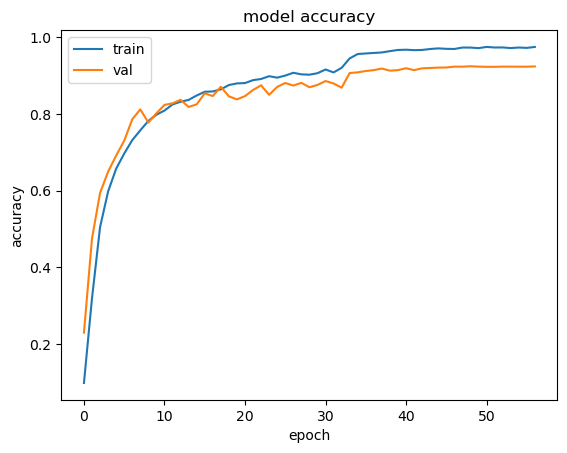

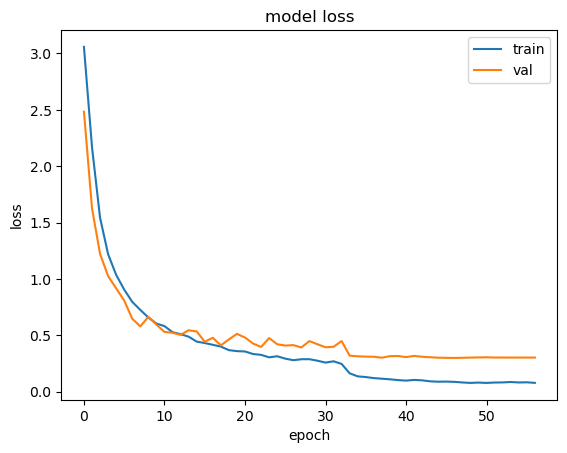

214/214 ━━━━━━━━━━━━━━━━━━━━ 28s 126ms/step


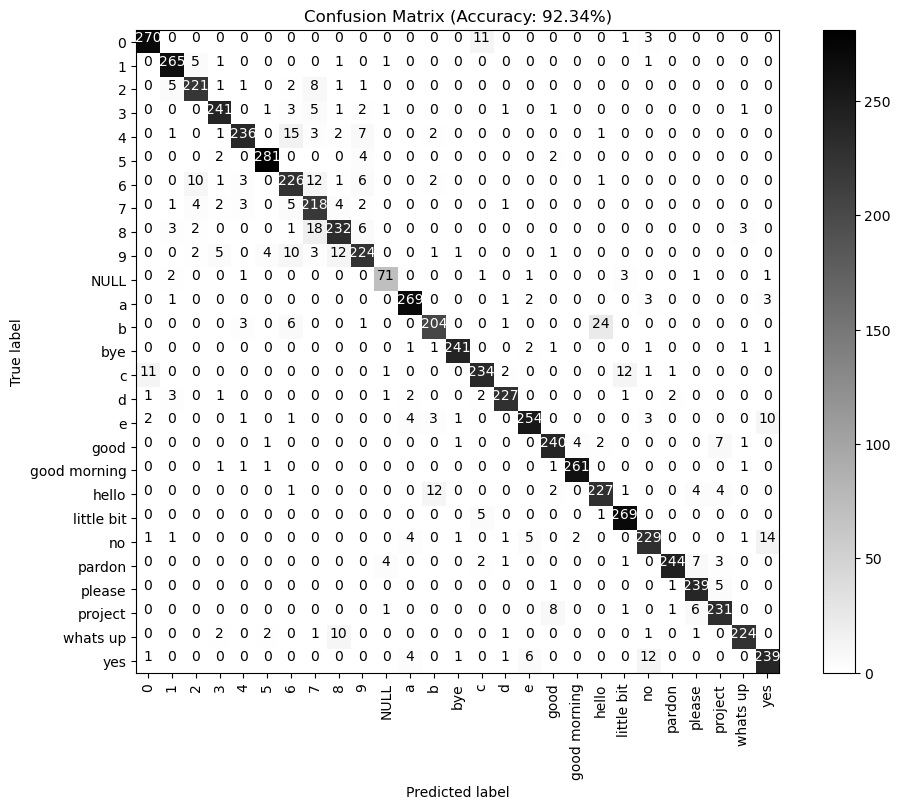

In [125]:
# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test)
print('Test accuracy:', accuracy)

# Plot accuracy curve
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc = 'upper left')
plt.show()

# Plot loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc = 'upper right')
plt.show()

# Confusion Matrix
# Calculate predictions
y_pred = model.predict(x_test)

# Convert one-hot encoded predictions back to integer labels
y_pred_labels = np.argmax(y_pred, axis = 1)
y_true_labels = np.argmax(y_test, axis = 1)

# Compute the confusion matrix
confusion_mtx = confusion_matrix(y_true_labels, y_pred_labels)

# Calculate accuracy
accuracy = accuracy_score(y_true_labels, y_pred_labels)

# Define the binary colormap
cmap = plt.cm.binary

# Create a figure with a larger size
plt.figure(figsize = (10, 8))

# Plot the confusion matrix
plt.imshow(confusion_mtx, interpolation = 'nearest', cmap = cmap)
plt.title(f'Confusion Matrix (Accuracy: {accuracy * 100:.2f}%)')

# Add labels for clarity
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation = 90)
plt.yticks(tick_marks, classes)

# Add text annotations for each cell
thresh = confusion_mtx.max() / 2.
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, format(confusion_mtx[i, j], 'd'), horizontalalignment = "center", color = "white" if confusion_mtx[i, j] > thresh else "black")

plt.colorbar()
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

## Evaluation Metrics

### *Weighted Evaluation Metrics*

Η χρήση του "weighted" μέσου όρου στους υπολογισμούς της precision, recall και F1 score εφαρμόζεται συχνά σε μη ισορροπημένα σύνολα δεδομένων (imbalanced datasets).Σε προβλήματα με μη ισορροπημένα δεδομένα, η χρήση σταθμισμένων μετρικών είναι απαραίτητη για να αποτυπώσει τη συνολική απόδοση του μοντέλου με δίκαιο τρόπο. Ο σταθμισμένος μέσος όρος λαμβάνει υπόψη το μέγεθος κάθε κατηγορίας, προσδίδοντας περισσότερο βάρος στις μεγαλύτερες κατηγορίες:

* Weighted Accuracy: Λαμβάνει υπόψη την ανισορροπία και υπολογίζει την ακρίβεια με βάση τη συχνότητα των κατηγοριών.
* Weighted Precision: Μειώνει την επίδραση των συχνότερων κατηγοριών και προσδίδει βάρη ανάλογα με τον αριθμό δειγμάτων.
* Weighted Recall: Υπολογίζει τη συνολική ευαισθησία, δίνοντας βαρύτητα στις κατηγορίες με μεγαλύτερη παρουσία.
* Weighted F1 Score: Εξισορροπεί την precision και την recall με βάση τα δεδομένα, παρέχοντας μια πιο αντιπροσωπευτική εικόνα της απόδοσης.


In [132]:
# Calculate precision, recall, and F1 score for a multiclass problem
precision = precision_score(y_true_labels, y_pred_labels, average = 'weighted')
recall = recall_score(y_true_labels, y_pred_labels, average = 'weighted')
f1 = f1_score(y_true_labels, y_pred_labels, average = 'weighted')

# Print the scores
print(f'Accuracy: {accuracy:.5f}')
print(f'Precision: {precision:.5f}')
print(f'Recall: {recall:.5f}')
print(f'F1 Score: {f1:.5f}')

Accuracy: 0.92340
Precision: 0.92411
Recall: 0.92340
F1 Score: 0.92344


### Συμπεράσματα για το Μοντέλο

Με βάση τα αποτελέσματα των evaluation metrics, μπορούμε να βγάλουμε τα εξής συμπεράσματα για το μοντέλο μας:
1. Γενική Απόδοση:
* Το μοντέλο έχει υψηλή ακρίβεια και καλή ισορροπία μεταξύ precision και recall. Με 92.34% ακρίβεια και πολύ κοντινές τιμές στις άλλες μετρικές, το μοντέλο είναι ικανό να διαχειριστεί το πρόβλημα πολυκατηγορικής ταξινόμησης με σταθερή απόδοση.

2. Ισορροπία στις Κατηγορίες:
* Οι υψηλές και σχεδόν ίδιες τιμές για precision, recall, και F1 score υποδηλώνουν ότι το μοντέλο δεν παρουσιάζει σημαντική μεροληψία (bias) προς κάποια κατηγορία και αποδίδει καλά σε όλες τις κλάσεις.

3. Αξιοπιστία σε Ανισόρροπα Δεδομένα:
* Δεδομένου ότι χρησιμοποιήθηκε ο σταθμισμένος μέσος όρος (average='weighted'), το μοντέλο προσαρμόζεται στην ανισορροπία των δεδομένων, προσδίδοντας μεγαλύτερη βαρύτητα στις κατηγορίες με περισσότερα δείγματα.


Επομένως το μοντέλο φαίνεται να έχει εξαιρετική απόδοση με υψηλή ακρίβεια και ισορροπία (μεταξύ precision και recall) και τα παραπάνω metrics μας υποδεικνύουν ότι το μοντέλο είναι αξιόπιστο και καλά προσαρμοσμένο στο πρόβλημα που καλείται να λύσει(American Sign Language Recognition problem).